# AQI Visualizations: World Heatmap, Time Series & Causal Inference

This notebook produces:
1. **Animated world heatmap** — AQI change relative to Jan 2019 baseline (blue = improved, red = worsened)
2. **GIF animation** — Bi-weekly AQI changes from Jan 2019 to Dec 2022
3. **Line graphs** — AQI trends by country and city
4. **Causal inference plots** — Evidence that stricter lockdowns led to better AQI improvement

In [1]:
%pip install -q plotly Pillow kaleido


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.express as px
from PIL import Image
import io
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Project root: /Users/someshb/covid-air-pollution-causal-inference


In [3]:
# ── Constants ──

CITY_RENAMES = {'San Fran': 'San Francisco', 'Sao_Paulo': 'Sao Paulo', 'Mexico_City': 'Mexico City'}

COUNTRY_MAP = {
    'Berlin': 'Germany', 'London': 'United Kingdom', 'Mexico City': 'Mexico',
    'Paris': 'France', 'Sao Paulo': 'Brazil', 'Seoul': 'South Korea', 'Tokyo': 'Japan',
    'Beijing': 'China', 'Shanghai': 'China', 'Shenzhen': 'China',
    'Chengdu': 'China', 'Guangzhou': 'China',
}

PM25_BREAKPOINTS = [
    (0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
    (55.5, 150.4, 151, 200), (150.5, 250.4, 201, 300), (250.5, 350.4, 301, 400),
    (350.5, 500.4, 401, 500),
]

CITY_COORDS = {
    'Delhi': (28.6139, 77.2090), 'Bengaluru': (12.9716, 77.5946),
    'Mumbai': (19.0760, 72.8777), 'London': (51.5074, -0.1278),
    'Berlin': (52.5200, 13.4050), 'Paris': (48.8566, 2.3522),
    'Mexico City': (19.4326, -99.1332), 'Sao Paulo': (-23.5505, -46.6333),
    'Seoul': (37.5665, 126.9780), 'Tokyo': (35.6762, 139.6503),
    'Boston': (42.3601, -71.0589), 'Chicago': (41.8781, -87.6298),
    'Houston': (29.7604, -95.3698), 'Los Angeles': (34.0522, -118.2437),
    'New York': (40.7128, -74.0060), 'Phoenix': (33.4484, -112.0740),
    'San Francisco': (37.7749, -122.4194),
    'Beijing': (39.9042, 116.4074), 'Shanghai': (31.2304, 121.4737),
    'Shenzhen': (22.5431, 114.0579), 'Chengdu': (30.5728, 104.0668),
    'Guangzhou': (23.1291, 113.2644),
}

LOCKDOWN_DATES = {
    'Berlin': '2020-03-22', 'Boston': '2020-03-24', 'Chicago': '2020-03-21',
    'Delhi': '2020-03-25', 'Houston': '2020-03-24', 'London': '2020-03-23',
    'Los Angeles': '2020-03-19', 'Mexico City': '2020-03-30', 'Mumbai': '2020-03-25',
    'Bengaluru': '2020-03-25', 'New York': '2020-03-22', 'Paris': '2020-03-17',
    'Phoenix': '2020-03-31', 'San Francisco': '2020-03-17', 'Sao Paulo': '2020-03-24',
    'Seoul': '2020-02-23', 'Tokyo': '2020-04-07',
    'Beijing': '2020-01-23', 'Shanghai': '2020-01-23', 'Shenzhen': '2020-01-23',
    'Chengdu': '2020-01-23', 'Guangzhou': '2020-01-23',
}

# Oxford Stringency Index (avg Mar-Jun 2020) — from causal_modelling notebook
STRINGENCY_INDEX = {
    'India': 78.17, 'France': 77.79, 'Brazil': 71.25, 'USA': 64.68,
    'United Kingdom': 63.22, 'Germany': 62.97, 'Mexico': 61.48,
    'South Korea': 57.47, 'Japan': 47.50, 'China': 81.25,
}

def normalize_city(city):
    return CITY_RENAMES.get(str(city).strip(), str(city).strip())

def pm25_to_aqi(pm25):
    if pd.isna(pm25):
        return np.nan
    pm25 = float(pm25)
    if pm25 < 0:
        return np.nan
    for c_lo, c_hi, i_lo, i_hi in PM25_BREAKPOINTS:
        if c_lo <= pm25 <= c_hi:
            return round(((i_hi - i_lo) / (c_hi - c_lo)) * (pm25 - c_lo) + i_lo)
    return 500 if pm25 > 500.4 else np.nan

## 1. Data Loading

Load raw AQI data from India, USA, and Other Cities, merge into a single daily dataset, and filter to 2019–2022.

In [4]:
# ── India ──
india_frames = []
for path in sorted((RAW_DIR / 'India').glob('*.csv')):
    df = pd.read_csv(path)
    india_frames.append(pd.DataFrame({
        'date': pd.to_datetime(df['date']),
        'city': df['City'].map(normalize_city),
        'country': 'India',
        'aqi': pd.to_numeric(df['Index Value'], errors='coerce'),
    }))
india_daily = pd.concat(india_frames, ignore_index=True)

# ── USA ──
usa_frames = []
for city_dir in sorted((RAW_DIR / 'USA').iterdir()):
    if not city_dir.is_dir():
        continue
    city_name = normalize_city(city_dir.name)
    for path in sorted(city_dir.glob('*.csv')):
        df = pd.read_csv(path)
        usa_frames.append(pd.DataFrame({
            'date': pd.to_datetime(df['Date'], format='%m/%d/%Y'),
            'city': city_name,
            'country': 'USA',
            'aqi': pd.to_numeric(df['Daily AQI Value'], errors='coerce'),
        }))
usa_daily = pd.concat(usa_frames, ignore_index=True)

# ── Other Cities (PM2.5 → AQI conversion) ──
other_frames = []
for path in sorted((RAW_DIR / 'Other Cities' / 'cleaned').glob('*_clean.csv')):
    df = pd.read_csv(path)
    city_name = normalize_city(path.stem.replace('_clean', '').replace('_', ' '))
    country = COUNTRY_MAP[city_name]
    other_frames.append(pd.DataFrame({
        'date': pd.to_datetime(df['date']),
        'city': city_name,
        'country': country,
        'aqi': pd.to_numeric(df['pm25'], errors='coerce').map(pm25_to_aqi),
    }))
other_daily = pd.concat(other_frames, ignore_index=True)

# ── China (Kaggle — hourly readings, aggregated to monthly mid-point) ──
china_raw = pd.read_csv(RAW_DIR / 'china - Kaggle' / 'air_pollution_china.csv')
china_raw['date'] = pd.to_datetime(
    china_raw['Year'].astype(str) + '-' + china_raw['Month'].astype(str).str.zfill(2) + '-15'
)
china_daily = (
    china_raw.groupby(['date', 'City'], as_index=False)['AQI'].mean()
    .rename(columns={'City': 'city', 'AQI': 'aqi'})
)
china_daily['country'] = 'China'

# ── Merge & aggregate to one row per city-day ──
merged = pd.concat([india_daily, usa_daily, other_daily, china_daily], ignore_index=True)
merged = merged.dropna(subset=['aqi'])
merged = (
    merged.groupby(['date', 'city', 'country'], as_index=False)
    .agg(aqi=('aqi', 'mean'))
    .sort_values(['date', 'country', 'city'])
    .reset_index(drop=True)
)
merged['aqi'] = merged['aqi'].round(2)
merged['lat'] = merged['city'].map(lambda c: CITY_COORDS.get(c, (np.nan, np.nan))[0])
merged['lon'] = merged['city'].map(lambda c: CITY_COORDS.get(c, (np.nan, np.nan))[1])

# Filter to 2019–2022
merged = merged[(merged['date'] >= '2019-01-01') & (merged['date'] <= '2022-12-31')].copy()

print(f'Dataset: {len(merged):,} rows | {merged["city"].nunique()} cities | '
      f'{merged["date"].min().date()} to {merged["date"].max().date()}')
merged.groupby('country').agg(
    cities=('city', 'nunique'), rows=('aqi', 'count'), mean_aqi=('aqi', 'mean')
).round(1)

Dataset: 16,529 rows | 21 cities | 2019-01-01 to 2022-12-31


,cities,rows,mean_aqi
country,,,
Brazil,1,701,56.3
China,5,239,254.5
France,1,815,48.4
Germany,1,1197,39.0
India,3,4380,128.5
Mexico,1,727,60.7
South Korea,1,126,53.8
USA,7,7672,41.1
United Kingdom,1,672,39.3


## 2. Baseline & Relative AQI Change

Using the **first week of January 2019** as the baseline for each city, we compute the daily relative AQI change.
- **Negative** (blue) → air quality improved
- **Positive** (red) → air quality worsened

In [5]:
# Baseline = avg AQI during Jan 1-7 2019 per city
baseline_window = merged[(merged['date'] >= '2019-01-01') & (merged['date'] <= '2019-01-07')]
baseline_aqi = baseline_window.groupby('city')['aqi'].mean()
print('Baseline AQI (Jan 1-7, 2019) per city:')
print(baseline_aqi.sort_values(ascending=False).round(1).to_string())

# Keep only cities with valid baseline
merged = merged[merged['city'].isin(baseline_aqi.index)].copy()
merged['baseline'] = merged['city'].map(baseline_aqi)
merged['relative_change'] = ((merged['aqi'] - merged['baseline']) / merged['baseline'] * 100).round(2)

# ── Weekly aggregation for animation (smoother + better performance) ──
weekly = (
    merged.set_index('date')
    .groupby('city')
    .resample('W')
    .agg(aqi=('aqi', 'mean'), relative_change=('relative_change', 'mean'),
         country=('country', 'first'), lat=('lat', 'first'),
         lon=('lon', 'first'), baseline=('baseline', 'first'))
    .reset_index()
    .dropna(subset=['aqi'])
)
weekly['aqi'] = weekly['aqi'].round(1)
weekly['relative_change'] = weekly['relative_change'].round(1)

# Fill gaps so every city appears in every week (smooth animation)
all_combos = pd.MultiIndex.from_product(
    [weekly['city'].unique(), sorted(weekly['date'].unique())], names=['city', 'date']
)
weekly = (
    weekly.set_index(['city', 'date'])
    .reindex(all_combos)
    .reset_index()
    .sort_values(['city', 'date'])
)
for col in ['country', 'lat', 'lon', 'baseline']:
    weekly[col] = weekly.groupby('city')[col].ffill().bfill()
for col in ['aqi', 'relative_change']:
    weekly[col] = weekly.groupby('city')[col].ffill()
weekly['week_label'] = weekly['date'].dt.strftime('%Y-%m-%d')
weekly = weekly.dropna(subset=['relative_change'])

print(f'\nWeekly data: {len(weekly):,} rows | {weekly["city"].nunique()} cities | '
      f'{weekly["week_label"].nunique()} weeks')

Baseline AQI (Jan 1-7, 2019) per city:
city
Delhi            389.9
Mumbai           197.1
Bengaluru        105.3
Paris             55.3
London            48.7
Los Angeles       48.6
Phoenix           48.6
Chicago           46.5
San Francisco     43.6
New York          41.9
Houston           37.1
Boston            34.3
Berlin            29.6

Weekly data: 2,717 rows | 13 cities | 209 weeks


## 3. Animated World Heatmap (Interactive)

Plotly scatter-geo animation with a play/pause button and weekly slider.
**Blue** = AQI decreased (improved) · **Red** = AQI increased (worsened)

In [6]:
fig = px.scatter_geo(
    weekly,
    lat='lat', lon='lon',
    color='relative_change',
    hover_name='city',
    hover_data={'country': True, 'aqi': ':.1f', 'relative_change': ':.1f',
                'lat': False, 'lon': False, 'week_label': False, 'baseline': False},
    animation_frame='week_label',
    color_continuous_scale='RdBu_r',
    range_color=[-100, 100],
    projection='natural earth',
    title='AQI Change Relative to January 2019 Baseline',
)

fig.update_traces(marker=dict(size=14, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    coloraxis_colorbar=dict(
        title='AQI Change (%)',
        tickvals=[-100, -50, 0, 50, 100],
        ticktext=['-100% (Better)', '-50%', '0% (Same)', '+50%', '+100% (Worse)'],
    ),
    geo=dict(
        showcountries=True, countrycolor='lightgray',
        showcoastlines=True, coastlinecolor='gray',
        showland=True, landcolor='#f3f3f3',
        showocean=True, oceancolor='#cce5ff',
    ),
    width=1100, height=600,
    sliders=[dict(currentvalue=dict(prefix='Week of: '), pad=dict(t=50))],
)

# Save interactive HTML
html_path = OUTPUT_DIR / 'aqi_world_heatmap_animated.html'
fig.write_html(str(html_path), auto_open=False)
print(f'Saved interactive HTML: {html_path}')

# Save static PNG (first animation frame)
map_png_path = OUTPUT_DIR / 'aqi_world_heatmap_animated.png'
fig.write_image(str(map_png_path), width=1100, height=600, scale=2)
print(f'Saved static PNG: {map_png_path}')

fig.show()

Saved interactive HTML: /Users/someshb/covid-air-pollution-causal-inference/outputs/figures/aqi_world_heatmap_animated.html
Saved static PNG: /Users/someshb/covid-air-pollution-causal-inference/outputs/figures/aqi_world_heatmap_animated.png


In [7]:
# Line graph: weekly AQI relative change over time by city
line_fig = px.line(
    weekly.sort_values(['city', 'date']),
    x='date',
    y='relative_change',
    color='city',
    hover_data={
        'country': True,
        'aqi': ':.1f',
        'baseline': ':.1f',
        'lat': False,
        'lon': False,
        'week_label': False,
    },
    title='Weekly AQI Change Relative to January 2019 Baseline (by City)',
)

line_fig.add_hline(y=0, line_dash='dash', line_color='black', opacity=0.6)

line_fig.update_layout(
    xaxis_title='Week',
    yaxis_title='AQI Change (%)',
    width=1100,
    height=600,
    legend_title='City',
)

line_html_path = OUTPUT_DIR / 'aqi_weekly_line_by_city.html'
line_fig.write_html(str(line_html_path), auto_open=False)
print(f'Saved interactive line chart: {line_html_path}')

line_png_path = OUTPUT_DIR / 'aqi_weekly_line_by_city.png'
line_fig.write_image(str(line_png_path), width=1100, height=600, scale=2)
print(f'Saved static PNG: {line_png_path}')

line_fig.show()

Saved interactive line chart: /Users/someshb/covid-air-pollution-causal-inference/outputs/figures/aqi_weekly_line_by_city.html
Saved static PNG: /Users/someshb/covid-air-pollution-causal-inference/outputs/figures/aqi_weekly_line_by_city.png


## 4. World Heatmap GIF

Static frames rendered with matplotlib (bi-weekly), compiled into a looping GIF.

In [23]:
norm = TwoSlopeNorm(vmin=-100, vcenter=0, vmax=100)
cmap = plt.cm.RdBu_r

week_dates = sorted(weekly['date'].unique())
sample_dates = week_dates[::2]  # bi-weekly for manageable GIF size

frames = []
for i, week_date in enumerate(sample_dates):
    wk = weekly[weekly['date'] == week_date]

    fig, ax = plt.subplots(figsize=(13, 6.5), facecolor='white')
    ax.set_facecolor('#dceefb')

    sc = ax.scatter(
        wk['lon'], wk['lat'], c=wk['relative_change'],
        cmap=cmap, norm=norm, s=160, edgecolors='black', linewidth=0.6, zorder=5,
    )

    for _, row in wk.iterrows():
        ax.annotate(
            row['city'], (row['lon'], row['lat']),
            textcoords='offset points', xytext=(8, 5),
            fontsize=6.5, color='#222', fontweight='bold',
        )

    ax.set_xlim(-135, 155)
    ax.set_ylim(-40, 62)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    date_str = pd.Timestamp(week_date).strftime('%b %d, %Y')
    ax.set_title(
        f'AQI Change from Jan 2019 Baseline  \u2014  {date_str}',
        fontsize=13, fontweight='bold',
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.02)
    cbar.set_label('AQI Change (%)')
    cbar.set_ticks([-100, -50, 0, 50, 100])

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)

    if (i + 1) % 25 == 0:
        print(f'  Rendered frame {i + 1}/{len(sample_dates)}')

gif_path = OUTPUT_DIR / 'aqi_world_heatmap.gif'
frames[0].save(
    str(gif_path), save_all=True, append_images=frames[1:], duration=180, loop=0,
)
print(f'\nSaved GIF ({len(frames)} frames): {gif_path}')

  Rendered frame 25/105
  Rendered frame 50/105
  Rendered frame 75/105
  Rendered frame 100/105

Saved GIF (105 frames): /Users/someshb/covid-air-pollution-causal-inference/outputs/figures/aqi_world_heatmap.gif


## 5. AQI Time-Series Line Graphs

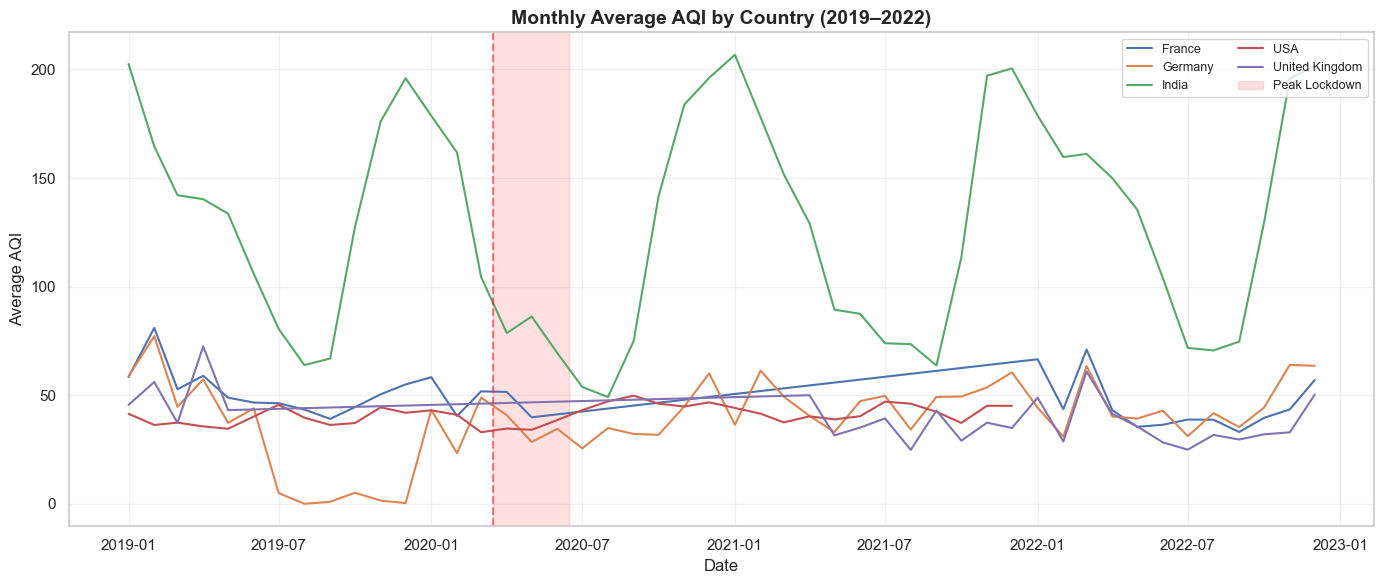

In [8]:
# Monthly average AQI by country
monthly = (
    merged.assign(month=merged['date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'country'], as_index=False)['aqi'].mean()
)

fig, ax = plt.subplots(figsize=(14, 6))
for country in sorted(monthly['country'].unique()):
    sub = monthly[monthly['country'] == country]
    ax.plot(sub['month'], sub['aqi'], label=country, linewidth=1.5)

ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2020-06-15'),
           alpha=0.12, color='red', label='Peak Lockdown')
ax.axvline(pd.Timestamp('2020-03-15'), color='red', ls='--', alpha=0.5)

ax.set_xlabel('Date')
ax.set_ylabel('Average AQI')
ax.set_title('Monthly Average AQI by Country (2019\u20132022)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aqi_monthly_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

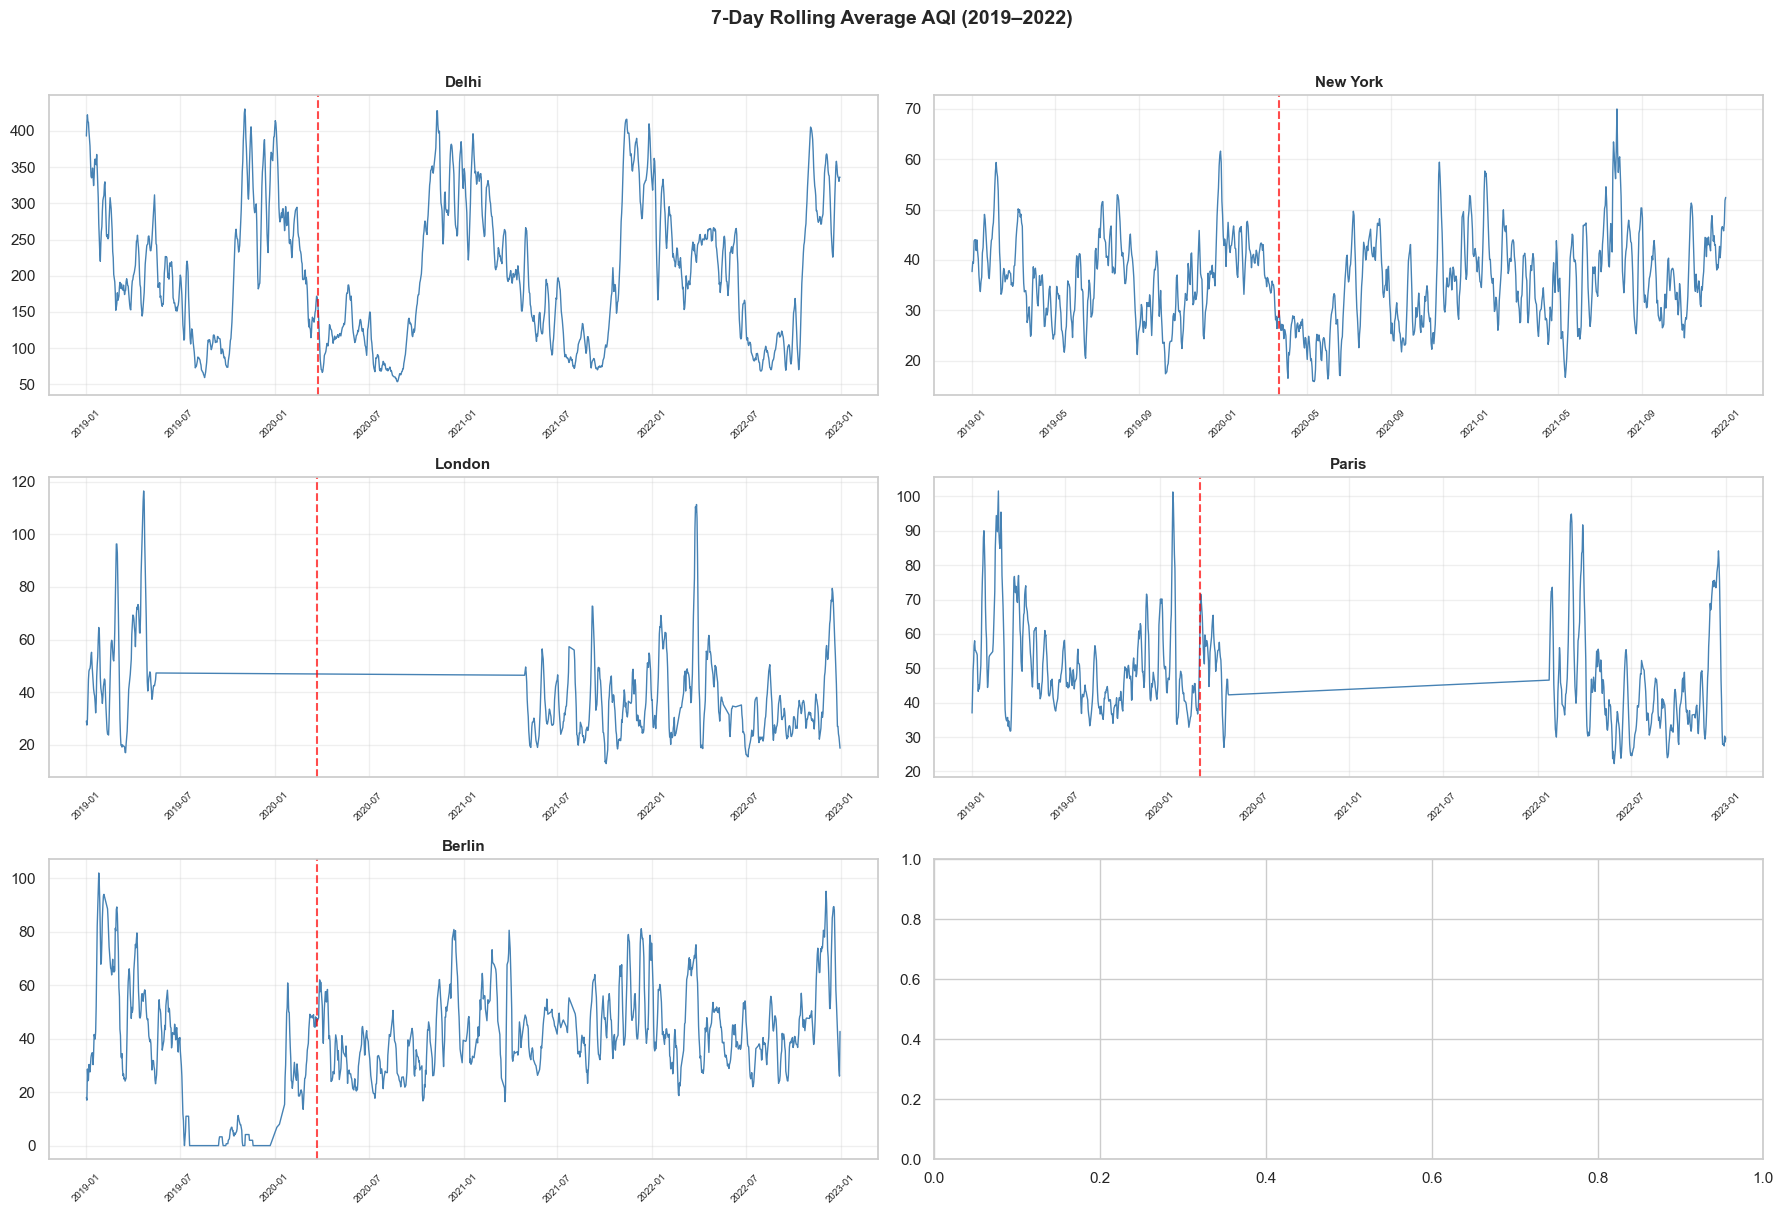

In [9]:
# 7-day rolling AQI for 5 key cities (only 5 panels)
key_cities = ['Delhi', 'New York', 'London', 'Paris', 'Berlin']
city_data = merged[merged['city'].isin(key_cities)].sort_values(['city', 'date']).copy()
city_data['aqi_7d'] = city_data.groupby('city')['aqi'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharey=False)
for i, city in enumerate(key_cities):
    ax = axes.flat[i]
    sub = city_data[city_data['city'] == city]
    ax.plot(sub['date'], sub['aqi_7d'], linewidth=1, color='steelblue')
    lockdown = LOCKDOWN_DATES.get(city)
    if lockdown:
        ax.axvline(pd.Timestamp(lockdown), color='red', ls='--', alpha=0.7, label='Lockdown')
    ax.set_title(city, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('7-Day Rolling Average AQI (2019\u20132022)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aqi_city_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Causal Inference Visualizations

Showing that countries with stricter COVID-19 lockdowns experienced greater AQI improvement.

**Treatment groups** (Oxford Stringency Index, Mar\u2013Jun 2020):
- *Treated* (high stringency): India (78), France (78), Brazil (71)
- *Control* (lower stringency): USA (65), UK (63), Germany (63), Mexico (61), S. Korea (57), Japan (48)

In [10]:
TREATED_COUNTRIES = ['India', 'France', 'Brazil']

causal = merged[(merged['date'] >= '2019-01-01') & (merged['date'] <= '2021-12-31')].copy()
causal['treated'] = causal['country'].isin(TREATED_COUNTRIES).astype(int)
causal['post'] = (causal['date'] >= '2020-03-15').astype(int)
causal['did'] = causal['treated'] * causal['post']
causal['stringency'] = causal['country'].map(STRINGENCY_INDEX)

print(f'Causal dataset: {len(causal):,} rows  |  '
      f'Treated: {(causal["treated"]==1).sum():,}  |  Control: {(causal["treated"]==0).sum():,}')

Causal dataset: 12,655 rows  |  Treated: 3,772  |  Control: 8,883


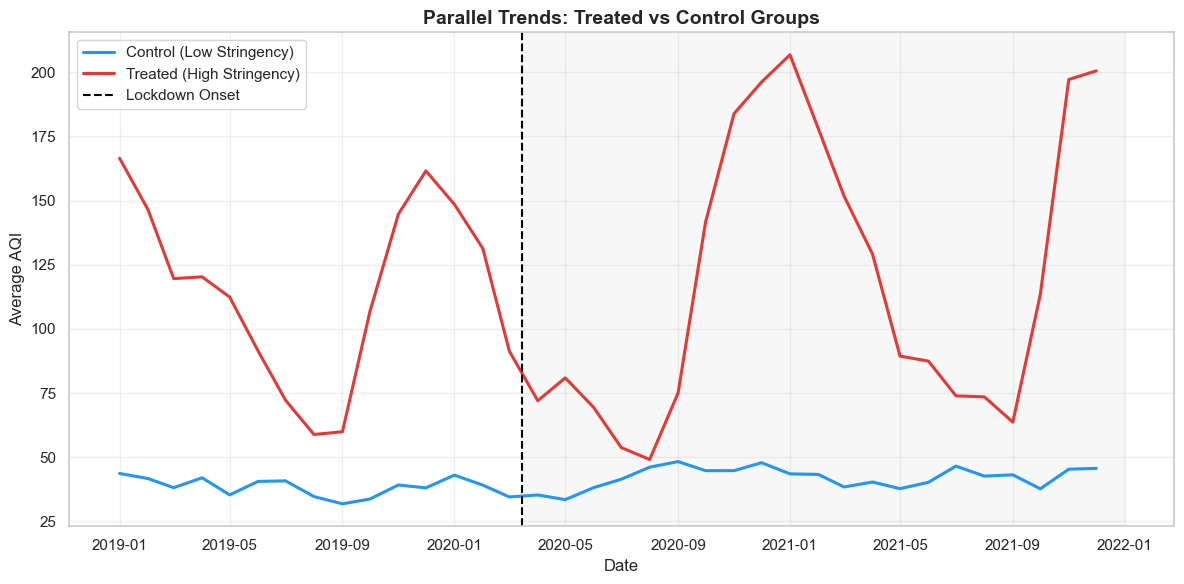

In [11]:
# Parallel trends — monthly treated vs control
monthly_trend = (
    causal.assign(month=causal['date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'treated'], as_index=False)['aqi'].mean()
)

fig, ax = plt.subplots(figsize=(12, 6))
labels = {0: 'Control (Low Stringency)', 1: 'Treated (High Stringency)'}
colors = {0: '#2196F3', 1: '#E53935'}
for t in [0, 1]:
    sub = monthly_trend[monthly_trend['treated'] == t]
    ax.plot(sub['month'], sub['aqi'], label=labels[t], color=colors[t], linewidth=2.2)

ax.axvline(pd.Timestamp('2020-03-15'), color='black', ls='--', lw=1.5, label='Lockdown Onset')
ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2021-12-31'), alpha=0.06, color='gray')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.set_title('Parallel Trends: Treated vs Control Groups', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'causal_parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()

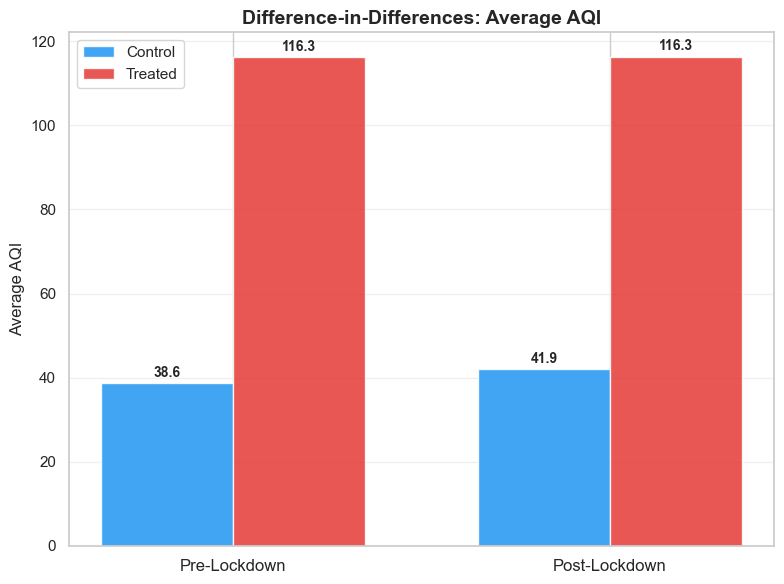


DiD estimate: -3.29
(Negative = treated group improved more than control)


In [12]:
did_means = causal.groupby(['treated', 'post'])['aqi'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
bw = 0.35
x = np.arange(2)
for t, label, color in [(0, 'Control', '#2196F3'), (1, 'Treated', '#E53935')]:
    vals = did_means[did_means['treated'] == t].sort_values('post')['aqi'].values
    bars = ax.bar(x + t * bw, vals, bw, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x + bw / 2)
ax.set_xticklabels(['Pre-Lockdown', 'Post-Lockdown'], fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.set_title('Difference-in-Differences: Average AQI', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'causal_did_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

# DiD estimate
pre_gap = did_means.query('post==0').set_index('treated')['aqi'].diff().iloc[-1]
post_gap = did_means.query('post==1').set_index('treated')['aqi'].diff().iloc[-1]
print(f'\nDiD estimate: {post_gap - pre_gap:.2f}')
print('(Negative = treated group improved more than control)')

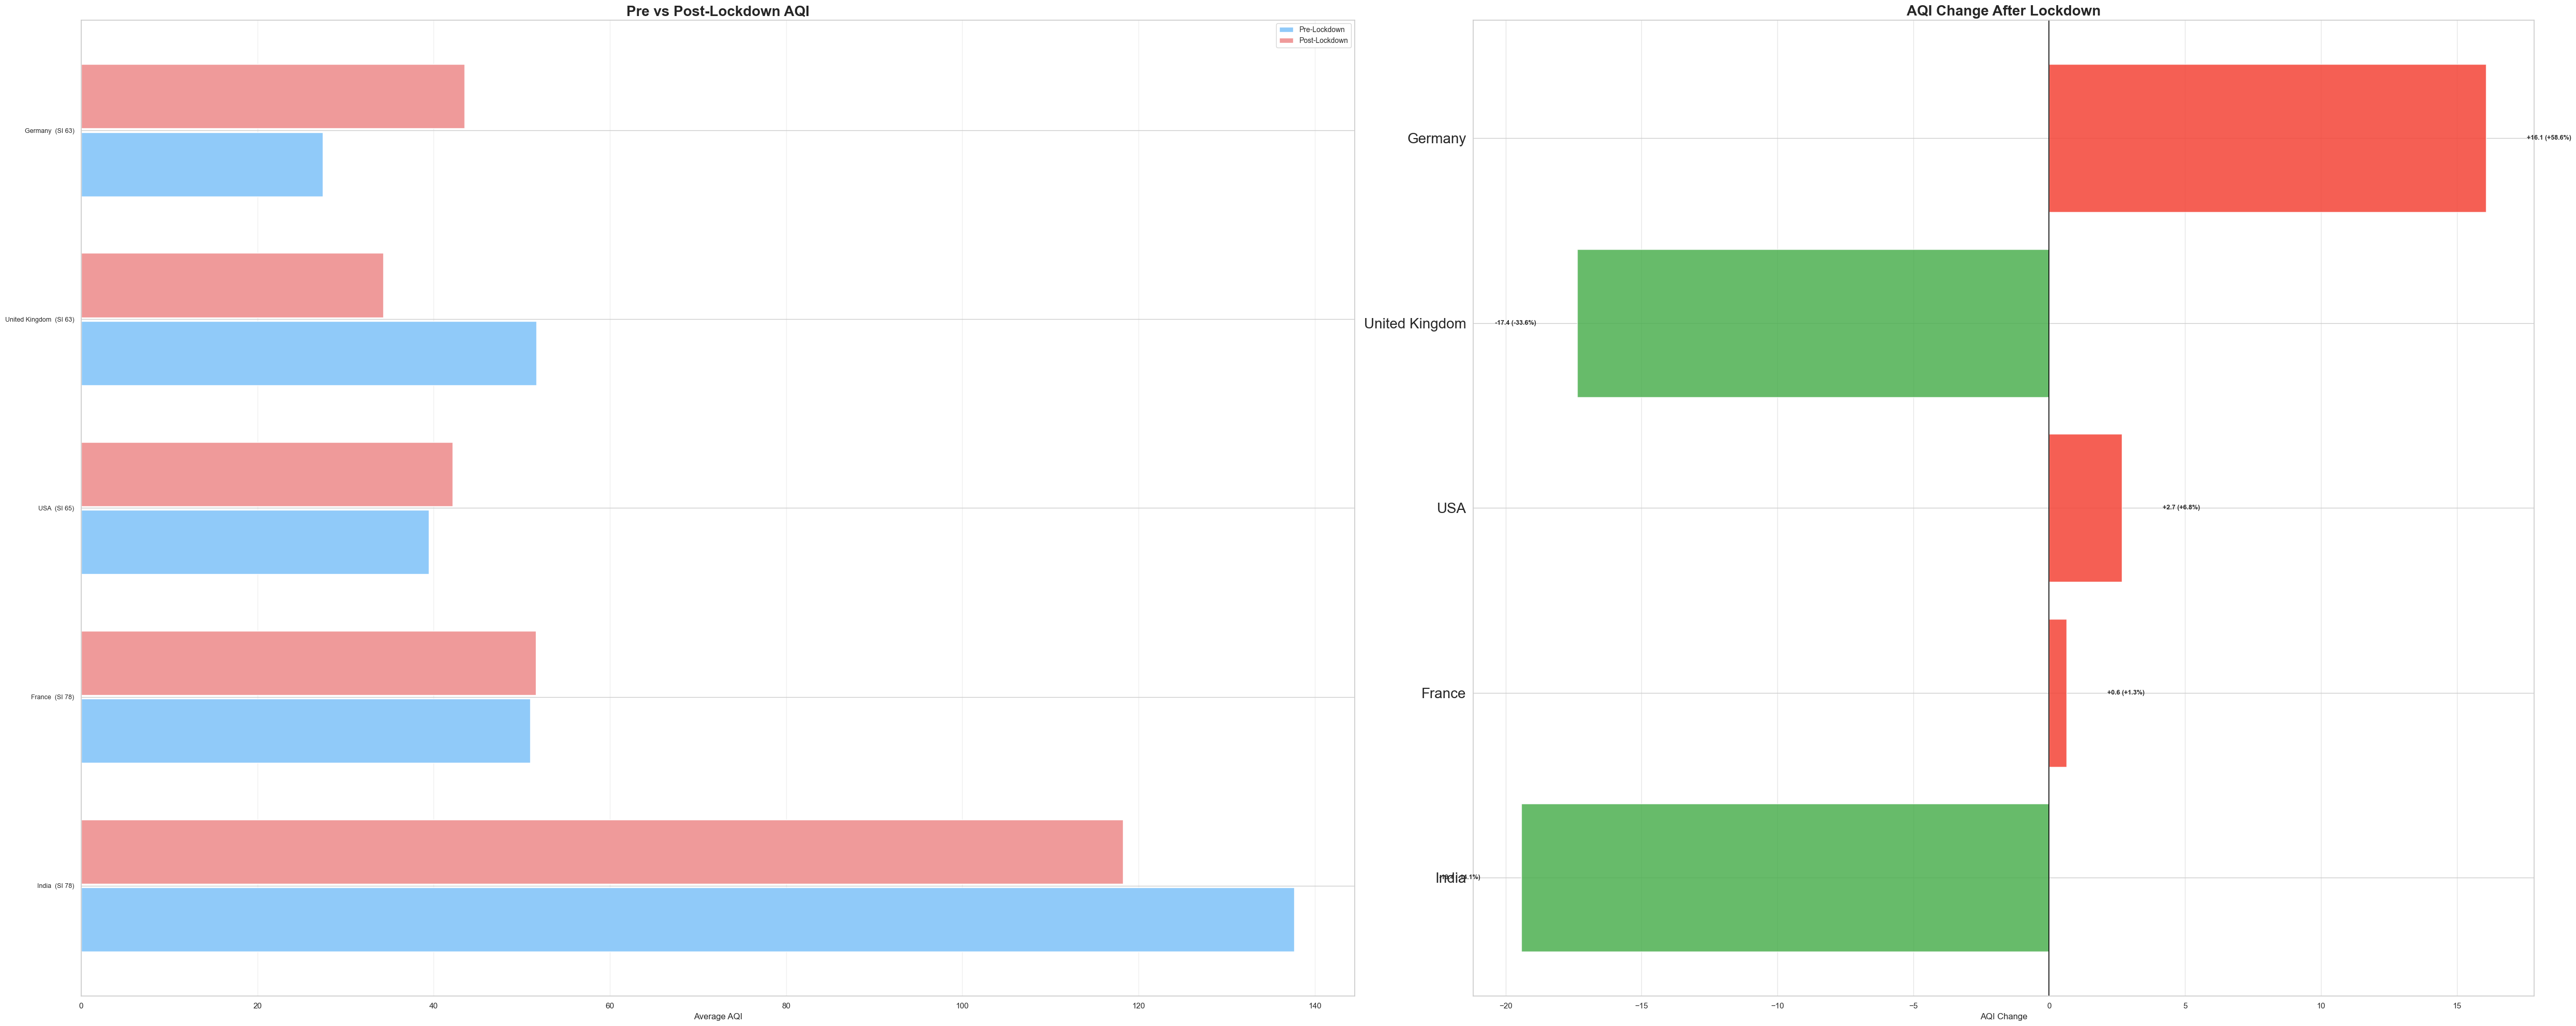

In [13]:
country_change = (
    causal.groupby(['country', 'post'])['aqi'].mean()
    .unstack().rename(columns={0: 'pre', 1: 'post_lockdown'})
)
country_change['change'] = country_change['post_lockdown'] - country_change['pre']
country_change['change_pct'] = (country_change['change'] / country_change['pre'] * 100).round(1)
country_change['stringency'] = country_change.index.map(STRINGENCY_INDEX)
country_change = country_change.sort_values('stringency', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(50, 20), gridspec_kw={'width_ratios': [1.2, 1]})

# Left: pre vs post bars
y = np.arange(len(country_change))
ax1.barh(y - 0.18, country_change['pre'], 0.34, label='Pre-Lockdown', color='#90CAF9')
ax1.barh(y + 0.18, country_change['post_lockdown'], 0.34, label='Post-Lockdown', color='#EF9A9A')
ax1.set_yticks(y)
ax1.set_yticklabels(
    [f'{c}  (SI {country_change.loc[c, "stringency"]:.0f})' for c in country_change.index], fontsize=9
)
ax1.set_xlabel('Average AQI')
ax1.set_title('Pre vs Post-Lockdown AQI', fontsize=20, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='x')

# Right: AQI change
bar_colors = ['#4CAF50' if v < 0 else '#F44336' for v in country_change['change']]
ax2.barh(y, country_change['change'], color=bar_colors, alpha=0.85)
for i, (val, pct) in enumerate(zip(country_change['change'], country_change['change_pct'])):
    offset = 1.5 if val >= 0 else -1.5
    ha = 'left' if val >= 0 else 'right'
    ax2.text(val + offset, i, f'{val:+.1f} ({pct:+.1f}%)', va='center', ha=ha, fontsize=9, fontweight='bold')
ax2.set_yticks(y)
ax2.set_yticklabels(country_change.index, fontsize=20)
ax2.axvline(0, color='black', linewidth=1.2)
ax2.set_xlabel('AQI Change')
ax2.set_title('AQI Change After Lockdown', fontsize=20, fontweight='bold')
ax2.grid(True, alpha=0.5, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'causal_country_comparison.png', dpi=250, bbox_inches='tight')
plt.show()

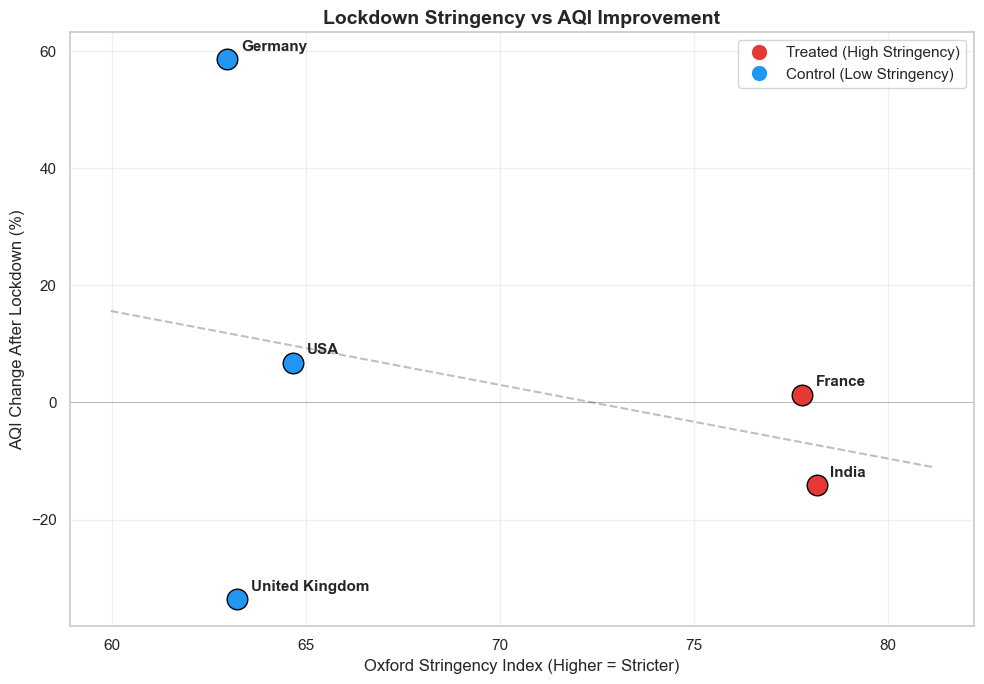

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

for country in country_change.index:
    row = country_change.loc[country]
    color = '#E53935' if country in TREATED_COUNTRIES else '#2196F3'
    ax.scatter(row['stringency'], row['change_pct'], s=220, c=color,
               edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(country, (row['stringency'], row['change_pct']),
                textcoords='offset points', xytext=(10, 6), fontsize=11, fontweight='bold')

# Trend line
x_vals = country_change['stringency'].dropna().values
y_vals = country_change.loc[country_change['stringency'].dropna().index, 'change_pct'].values
if len(x_vals) > 1:
    coeffs = np.polyfit(x_vals, y_vals, 1)
    xl = np.linspace(x_vals.min() - 3, x_vals.max() + 3, 100)
    ax.plot(xl, np.polyval(coeffs, xl), '--', color='gray', alpha=0.5, lw=1.5)

ax.axhline(0, color='black', lw=0.5, alpha=0.3)
ax.set_xlabel('Oxford Stringency Index (Higher = Stricter)', fontsize=12)
ax.set_ylabel('AQI Change After Lockdown (%)', fontsize=12)
ax.set_title('Lockdown Stringency vs AQI Improvement', fontsize=14, fontweight='bold')

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E53935', markersize=12,
           label='Treated (High Stringency)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=12,
           label='Control (Low Stringency)'),
]
ax.legend(handles=legend_handles, fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'causal_stringency_vs_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

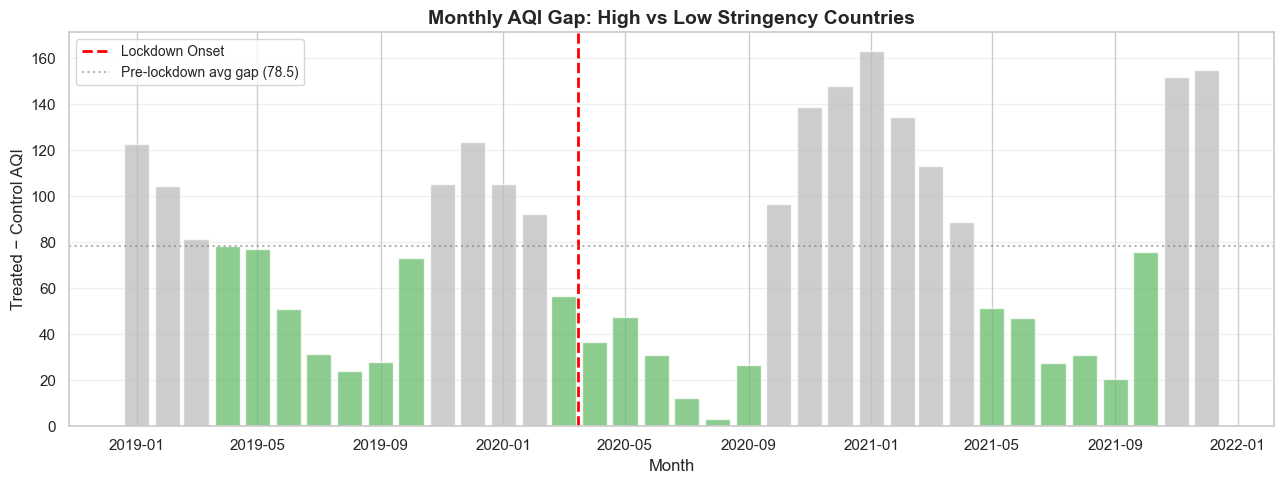

In [15]:
monthly_did = (
    causal.assign(month=causal['date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'treated'], as_index=False)['aqi'].mean()
    .pivot(index='month', columns='treated', values='aqi')
    .rename(columns={0: 'control', 1: 'treated'})
)
monthly_did['gap'] = monthly_did['treated'] - monthly_did['control']
pre_avg = monthly_did.loc[:'2020-02', 'gap'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ['#66BB6A' if g < pre_avg else '#BDBDBD' for g in monthly_did['gap']]
ax.bar(monthly_did.index, monthly_did['gap'], width=25, color=bar_colors, alpha=0.75, edgecolor='white')
ax.axvline(pd.Timestamp('2020-03-15'), color='red', ls='--', lw=2, label='Lockdown Onset')
ax.axhline(pre_avg, color='gray', ls=':', alpha=0.6, label=f'Pre-lockdown avg gap ({pre_avg:.1f})')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Treated \u2212 Control AQI', fontsize=12)
ax.set_title('Monthly AQI Gap: High vs Low Stringency Countries', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'causal_monthly_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

**Outputs saved to `outputs/figures/`:**

| File | Description |
|------|-------------|
| `aqi_world_heatmap_animated.html` | Interactive world map with weekly slider |
| `aqi_world_heatmap.gif` | Animated GIF of AQI changes (2019\u20132022) |
| `aqi_monthly_by_country.png` | Monthly AQI line graph by country |
| `aqi_city_timeseries.png` | 7-day rolling AQI for 8 key cities |
| `causal_parallel_trends.png` | Pre/post parallel trends |
| `causal_did_barplot.png` | Difference-in-Differences bar chart |
| `causal_country_comparison.png` | Country-level pre vs post AQI |
| `causal_stringency_vs_aqi.png` | Stringency index vs AQI change scatter |
| `causal_monthly_gap.png` | Rolling monthly treatment effect |